## Test script to read .nc files in $SCRATCH and save what needed in $PERM

In [1]:
import xarray as xr
import numpy as np
import os
import dask
import h5netcdf
import scipy
import matplotlib.pyplot as plt
import pint
import dask
import netCDF4
from datetime import timedelta
import datetime


In [93]:
exp_name_in  = 'itvc_ctrl'
exp_name_out = 'itvc_ctrl'
levels   = 'ml' # ml / pl / srf 
ldiagflx = True

dir_in   = f"/scratch/paaa/IFS/netherlands/{exp_name_in[0:4]}"
dir_out  = '/perm/paaa/IFS/netherlands' #/eps_nemo'
lead_time = 24

LDIAGFLX = {
    # dynamics
    'p212001' : 'dudt_dyn'    , 'p212002' : 'uflx_dyn'   ,
    'p212003' : 'dvdt_dyn'    , 'p212004' : 'vflx_dyn'   ,
    'p212005' : 'dTdt_dyn'    , 'p212006' : 'Tflx_dyn'   ,
    'p212007' : 'dqdt_dyn'    , 'p212008' : 'qflx_dyn'   ,
    'p212009' : 'dco2dt_dyn'  , 'p212010' : 'co2flx_dyn' ,
    'p212011' : 'dch4dt_dyn'  , 'p212012' : 'ch4flx_dyn' ,
    # diffusion
    'p212013' : 'dudt_diff'   , 'p212014' : 'uflx_diff'  ,
    'p212015' : 'dvdt_diff'   , 'p212016' : 'vflx_diff'  ,
    'p212017' : 'dTdt_diff'   , 'p212018' : 'Tflx_diff'  ,
    'p212019' : 'dqdt_diff'   , 'p212020' : 'qflx_diff'  ,
    'p212021' : 'dco2dt_diff' , 'p212022' : 'co2flx_diff',
    'p212023' : 'dch4dt_diff' , 'p212024' : 'ch4flx_diff',
    # convection
    'p212025' : 'dudt_conv'   , 'p212026' : 'uflx_conv'  ,
    'p212027' : 'dvdt_conv'   , 'p212028' : 'vflx_conv'  ,
    'p212029' : 'dTdt_conv'   , 'p212030' : 'Tflx_conv'  ,
    'p212031' : 'dqdt_conv'   , 'p212032' : 'qflx_conv'  ,
    'p212033' : 'dco2dt_conv' , 'p212034' : 'co2flx_conv',
    'p212035' : 'dch4dt_conv' , 'p212036' : 'ch4flx_conv',
    # cloud
    'p212037' : 'dTdt_cloud'  , 'p212038' : 'Tflx_cloud' ,
    'p212039' : 'dqdt_cloud'  , 'p212040' : 'qflx_cloud' ,
}


target_lead_times = [lead_time, lead_time + 12]
print(f"Looking for data in {dir_in}")
files = []
for lt in target_lead_times:
    matching_files = [
        os.path.join(dir_in, f)
        for f in os.listdir(dir_in)
        if exp_name_in in f
        and levels in f
        and f'_{lt}' in f
        # and f.lower().endswith(f'{subdomain.lower()}.nc')
        and f.lower().endswith('.nc')
    ]
    files.extend(matching_files)

files.sort()
print(f"Found these files for lead time {lead_time} (+12): {files}")

if files:
    ds = xr.open_mfdataset(
        files,
        combine='by_coords',
        chunks={'longitude': -1, 'latitude': -1, 'time': 50}
    )


################################################################
# Open also the file before or the file after for continuity in time when deaccumulating !!!!!
################################################################


Looking for data in /scratch/paaa/IFS/netherlands/itvc
Found these files for lead time 24 (+12): ['/scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220515_24.nc', '/scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220515_36.nc', '/scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220516_24.nc', '/scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220516_36.nc', '/scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220517_24.nc', '/scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220517_36.nc', '/scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220518_24.nc', '/scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220518_36.nc', '/scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220519_24.nc', '/scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220519_36.nc']


In [ ]:
## loop through the files and deaccumulate the fields that need it
# remove the variable ds_combined if it exists
if 'ds_combined' in locals():
    del ds_combined
for file in files:
    print(f"Processing file {file}")
    ds_single = xr.open_dataset(file, chunks={'longitude': -1, 'latitude': -1, 'time': 50})
    time_values = ds_single['time'].values
    # Calculate the time difference between consecutive time steps
    if len(time_values) > 1:
        time_diffs = np.diff(time_values) # in numpy timedelta64[ns] format
        # Assuming uniform time steps, take the first difference
        time_step = time_diffs[0].astype('timedelta64[h]')
    else:
        print("Not enough time points to calculate time step.")
    print(f"Time step between consecutive records: {time_step} hour")
    # update units of some variables
    for var in ['co2','q','clwc','ra','co','ch4']:
        if var in ds_single:
            ds_single[var] *= 1000 
            ds_single[var].attrs['units'] = r'g kg$^{-1}$'
        else:
            print(f"Variable {var} not found in dataset.")
    # rename experimental variables
    ds_single = ds_single.rename(LDIAGFLX)
    ## Loop through the variables
    for var, var_data in ds_single.variables.items():
        ## Assign units
        if 'dqdt' in var or 'dco2dt' in var or 'dch4dt' in var :
            ds_single[var] *= 1000 
            ds_single[var].attrs['units'] = r'g kg$^{-1}$'
        elif 'dTdt' in var:
            ds_single[var].attrs['units'] = r'K'
        elif 'dudt' in var:
            ds_single[var].attrs['units'] = r'm s$^{-1}$'
        elif 'dvdt' in var:
            ds_single[var].attrs['units'] = r'm s$^{-1}$'
        elif 'MF' in var:
            ds_single[var].attrs['units'] = r'kg m$^{-2}$s$^{-1}$'

        ## Assign long name 
        if var == 'dryMF':
            ds_single[var].attrs['long_name'] = 'Dry mass-flux'
        if var == 'dry_moistMF':
            ds_single[var].attrs['long_name'] = 'Combined dry and moist mass-flux'
        ## moisture 
        if var == 'dqdt_dyn':
            ds_single[var].attrs['long_name'] = 'Moisture tendency from dynamics'
        elif var == 'dqdt_diff':
            ds_single[var].attrs['long_name'] = 'Moisture tendency from diffusion and gravity waves'
        elif var == 'dqdt_conv':
            ds_single[var].attrs['long_name'] = 'Moisture tendency from convection'
        elif var == 'dqdt_cloud':
            ds_single[var].attrs['long_name'] = 'Moisture tendency from cloud'
        ## temperature 
        if var == 'dTdt_dyn':
            ds_single[var].attrs['long_name'] = 'Temperature tendency from dynamics'
        elif var == 'dTdt_diff':
            ds_single[var].attrs['long_name'] = 'Temperature tendency from diffusion and gravity waves'
        elif var == 'dTdt_conv':
            ds_single[var].attrs['long_name'] = 'Temperature tendency from convection'
        elif var == 'dTdt_cloud':
            ds_single[var].attrs['long_name'] = 'Temperature tendency from cloud'
        ## zonal wind 
        if var == 'dudt_dyn':
            ds_single[var].attrs['long_name'] = 'Zonal wind tendency from dynamics'
        elif var == 'dudt_diff':
            ds_single[var].attrs['long_name'] = 'Zonal wind tendency from diffusion and gravity waves'
        elif var == 'dudt_conv':
            ds_single[var].attrs['long_name'] = 'Zonal wind tendency from convection'
        ## meridional wind 
        if var == 'dvdt_dyn':
            ds_single[var].attrs['long_name'] = 'Meridional wind tendency from dynamics'
        elif var == 'dvdt_diff':
            ds_single[var].attrs['long_name'] = 'Meridional wind tendency from diffusion and gravity waves'
        elif var == 'dvdt_conv':
            ds_single[var].attrs['long_name'] = 'Meridional wind tendency from convection'
        ## CO2 
        if var == 'dco2dt_dyn':
            ds_single[var].attrs['long_name'] = 'CO2 tendency from dynamics'
        elif var == 'dco2dt_diff':
            ds_single[var].attrs['long_name'] = 'CO2 tendency from diffusion and gravity waves'
        elif var == 'dco2dt_conv':
            ds_single[var].attrs['long_name'] = 'CO2 tendency from convection'
        elif var == 'co2flx_dyn':
            ds_single[var].attrs['long_name'] = 'Time-integrated CO2 flux from dynamics'
        elif var == 'co2flx_diff':
            ds_single[var].attrs['long_name'] = 'Time-integrated CO2 flux from diffusion'
        elif var == 'co2flx_conv':
            ds_single[var].attrs['long_name'] = 'Time-integrated CO2 flux from convection'
        ## CH4
        if var == 'dch4dt_dyn':
            ds_single[var].attrs['long_name'] = 'CH4 tendency from dynamics'
        elif var == 'dch4dt_diff':
            ds_single[var].attrs['long_name'] = 'CH4 tendency from diffusion and gravity waves'
        elif var == 'dch4dt_conv':
            ds_single[var].attrs['long_name'] = 'CH4 tendency from convection'
        elif var == 'ch4flx_dyn':
            ds_single[var].attrs['long_name'] = 'Time-integrated CH4 flux from dynamics'
        elif var == 'ch4flx_diff':
            ds_single[var].attrs['long_name'] = 'Time-integrated CH4 flux from diffusion'
        elif var == 'ch4flx_conv':
            ds_single[var].attrs['long_name'] = 'Time-integrated CH4 flux from convection'

    ################################################
    ### Define a function to deaccumulate a variable
    def deaccumulate(var):
        var_diff = var.diff(dim='time', label='upper')
        # divide by the time step in hours to get rate per hour
        var_deaccumulated = var_diff / time_step.astype(float)
        # Copy attributes from the original dataset
        var_deaccumulated.attrs = var.attrs.copy()
        var_deaccumulated.attrs['units'] = var_deaccumulated.attrs['units'] +r' h$^{-1}$'
        return var_deaccumulated
    ################################################

    print(f"Deaccumulating...")
    # Select variables to deaccumulate (that contain 'dt')
    vars_to_deaccumulate = [var for var in ds_single.variables if 'dt' in var]
    # Select variables to deaccumulate (Time-integrated) from model level output
    for var in ds_single:
        if var in ['srta','trta','umfa','dmfa','udra','ddra','tdcha','dryMF','dry_moistMF']:
            vars_to_deaccumulate.append(var)
            ds_single[var].attrs['long_name'] = ds_single[var].attrs['long_name'].replace('Time-integrated', 'Deaccumulated').capitalize() # remove the string "Time-integrated..."
        if var in ['co2flx_dyn','co2flx_diff','co2flx_conv','ch4flx_dyn','ch4flx_diff','ch4flx_conv']:
            ds_single[var].attrs['units'] = 'g m$^{-2}$'
            vars_to_deaccumulate.append(var)
            ds_single[var].attrs['long_name'] = ds_single[var].attrs['long_name'].replace('Time-integrated', 'Deaccumulated').capitalize()

    # Deaccumulate each selected variable
    for var_name in vars_to_deaccumulate:
        if var_name in ds_single:
            # print(f"Deaccumulating variable: {var_name}")
            ds_single[var_name] = deaccumulate(ds_single[var_name])
        else:
            print(f"Variable {var_name} not found in dataset.")

    # After processing, drop the first time and concatenate all ds_single datasets
    ds_single = ds_single.isel(time=slice(1, None))
    if 'ds_combined' in locals():
        ds_combined = xr.concat([ds_combined, ds_single], dim='time')
    else:
        ds_combined = ds_single
print(f"Finished processing files________")

Processing file /scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220515_24.nc
Time step between consecutive records: 1 hours hour
Deaccumulating...
Processing file /scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220515_36.nc
Time step between consecutive records: 1 hours hour
Deaccumulating...
Processing file /scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220516_24.nc
Time step between consecutive records: 1 hours hour
Deaccumulating...
Processing file /scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220516_36.nc
Time step between consecutive records: 1 hours hour
Deaccumulating...
Processing file /scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220517_24.nc
Time step between consecutive records: 1 hours hour
Deaccumulating...
Processing file /scratch/paaa/IFS/netherlands/itvc/itvc_ctrl_flxntend_ml_20220517_36.nc
Time step between consecutive records: 1 hours hour
Deaccumulating...
Processing file /scratch/paaa/IFS/netherlands/itvc/i

#### Deaccumulate

Text(0.5, 1.0, 'CO2 flux from dco2dt_diff')

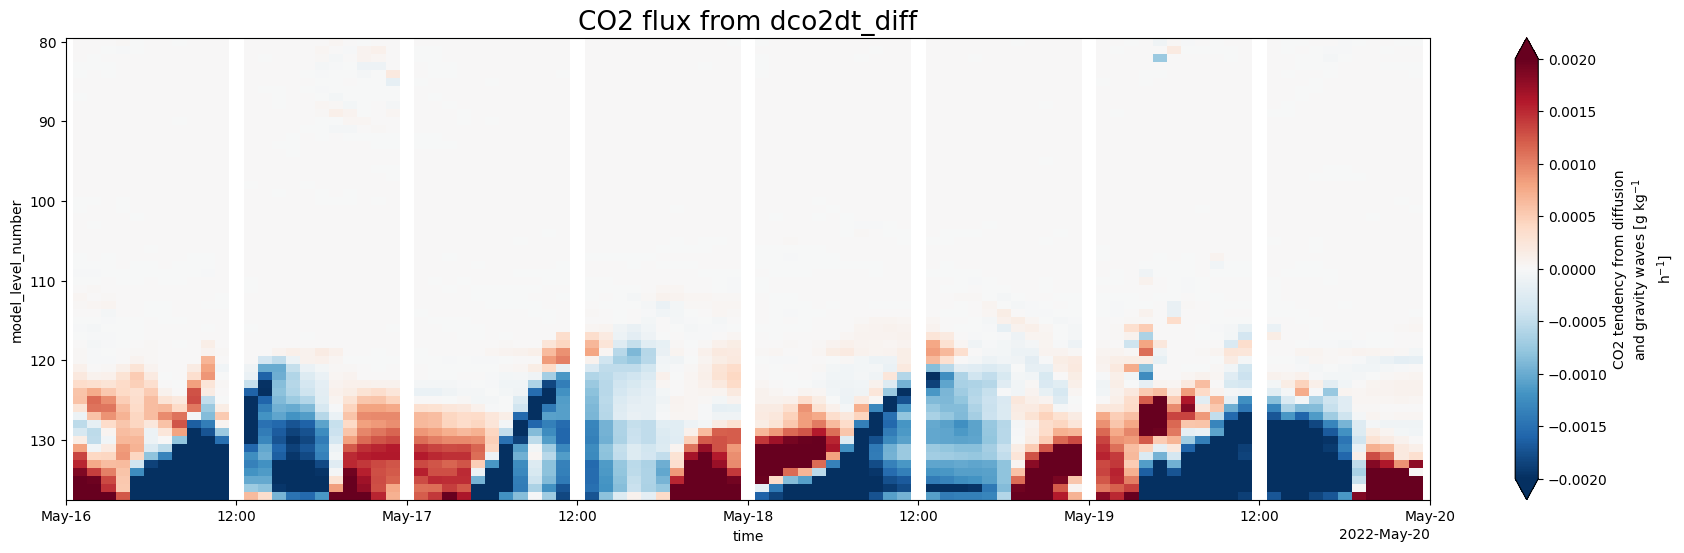

In [97]:
# var = 'co2flx_conv' 
var = 'dco2dt_diff'
str_time = '2022-05-16'
end_time = '2022-05-20'
plt.figure(figsize=(22,6))
ds_combined[var].isel(latitude=1, longitude=1).sel(level=slice(80,137)).plot(x='time',
                                                                            yincrease=False,
                                                                            vmin=-0.002)

plt.xlim((datetime.datetime.strptime(str_time, "%Y-%m-%d"),
          datetime.datetime.strptime(end_time, "%Y-%m-%d")))
plt.title(f'CO2 flux from {var}',fontsize = 19)

Text(0.5, 1.0, 'CO2 flux from dco2dt_diff')

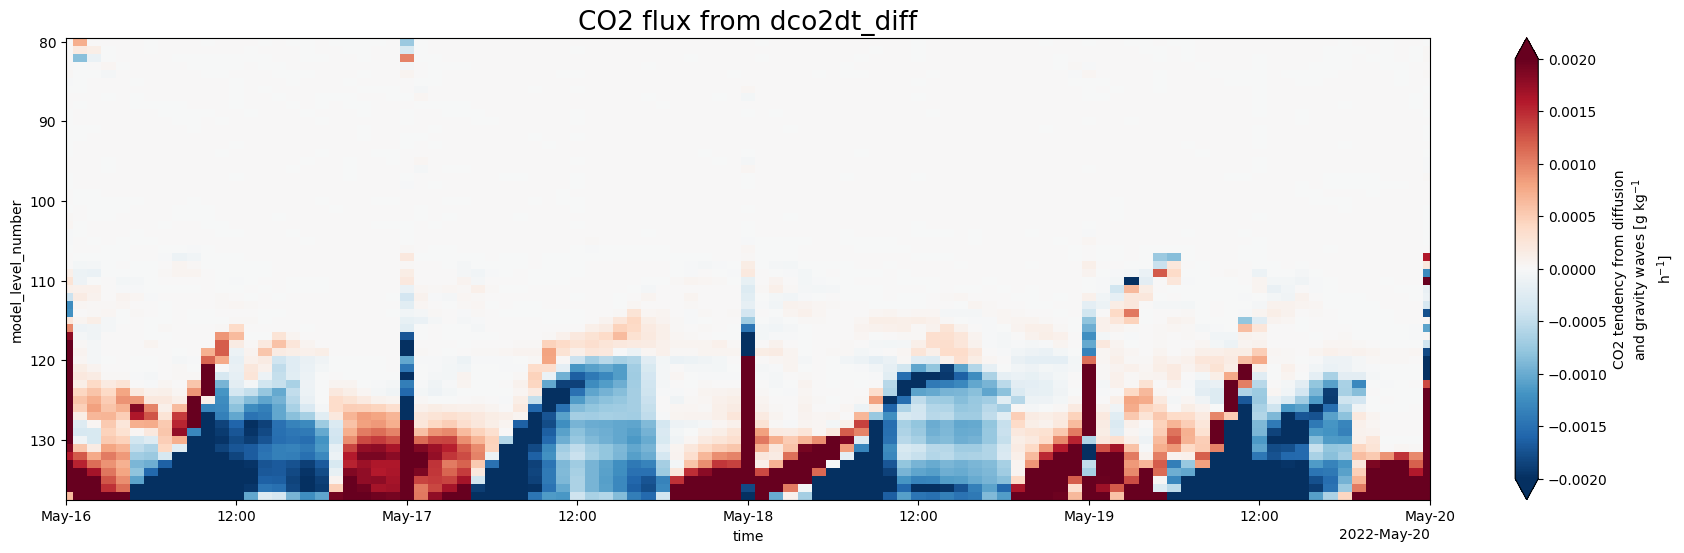

In [114]:
# var = 'co2flx_conv' 
var = 'dco2dt_diff'
str_time = '2022-05-16'
end_time = '2022-05-20'
plt.figure(figsize=(22,6))
ds_deaccumulated[var].isel(latitude=1, longitude=1).sel(level=slice(80,137)).plot(x='time',
                                                                            yincrease=False,
                                                                            vmin=-0.002)

plt.xlim((datetime.datetime.strptime(str_time, "%Y-%m-%d"),
          datetime.datetime.strptime(end_time, "%Y-%m-%d")))
plt.title(f'CO2 flux from {var}',fontsize = 19)


Text(0.5, 1.0, 'CO2 flux from convection')

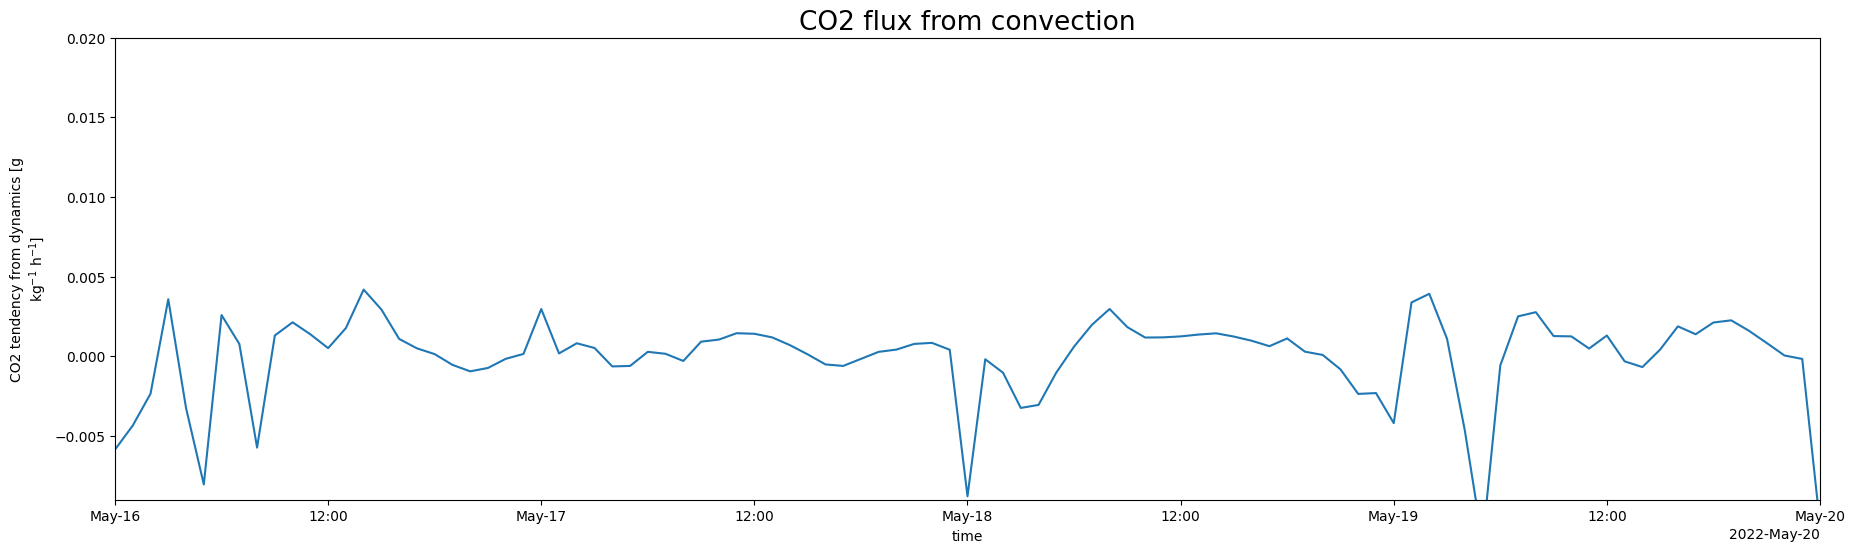

In [113]:

# var = 'co2flx_di' 
var = 'dco2dt_dyn'
str_time = '2022-05-16'
end_time = '2022-05-20'
plt.figure(figsize=(22,6))
ds_deaccumulated[var].isel(latitude=1, longitude=1).sel(level=125).plot(x='time')

plt.xlim((datetime.datetime.strptime(str_time, "%Y-%m-%d"),
          datetime.datetime.strptime(end_time, "%Y-%m-%d")))
plt.ylim(-0.009,0.02)
plt.title('CO2 flux from convection',fontsize = 19)


In [30]:
## I don't know why this is needed, but without it the saving goes wrong. Might be becasue of existing NaN values
ds = ds.map(lambda x: x.astype('float64'))
# ds = ds.drop_vars("dryMF")
ds

<xarray.Dataset> Size: 1MB
Dimensions:      (longitude: 6, latitude: 6, time: 144)
Coordinates:
  * longitude    (longitude) float32 24B 4.68 4.78 4.88 4.98 5.08 5.18
  * latitude     (latitude) float32 24B 52.22 52.12 52.02 51.92 51.82 51.72
  * time         (time) datetime64[ns] 1kB 2022-05-15T01:00:00 ... 2022-05-21
Data variables: (12/25)
    lai_lv       (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    lai_hv       (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    aco2nee      (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    aco2gpp      (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    aco2rec      (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    fco2nee      (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    ...           ...
    co2          (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    ch4          (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    co           (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    ra           (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    e_WLCH4      (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>
    acc_e_WLCH4  (time, latitude, longitude) float64 41kB dask.array<chunksize=(100, 6, 6), meta=np.ndarray>